In [ ]:
# notebook to define a set of eQTLs for comparison on an independent set
# couple notes:
# PIP >= 0.9
# drop genes with multiple causal variants, not necessarily multiple genes
# ie there is another eQTL in a different credible set with a PIP of ~ > 0.5
# also worth looking at cell type matched sets
# ie whole blood -> k562, tibial nerve/brain -> sk-n-sh, liver -> hepg2

In [1]:
# import packages
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy import stats
from tqdm import tqdm
from collections import Counter
import numpy as np
from sklearn import metrics
from collections import Counter
from sklearn.metrics import RocCurveDisplay

In [2]:
# define the path to the fine mapped variants as a variable
path2fineMapped = '/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/promoter_sat_mut_comp/raw_data/gtex_v10_fineMapping/SuSiE_fineMapped'
# define the path to the gtex info as a variable
path2gtex_v10 = '/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/promoter_sat_mut_comp/raw_data/gtex_v10_fineMapping/GTEx_Analysis_v10_eQTL_updated'

In [3]:
# iterate through all fine mapped variants and collapse into a single DF
fineMapped2cat = []
for i in tqdm([i for i in os.listdir(path2fineMapped) if i.endswith('.parquet')]):
    parqLife = pd.read_parquet(f'{path2fineMapped}/{i}')
    # add tissue column
    parqLife.loc[:,'tissue'] = [i.split('.')[0] for j in range(len(parqLife))]
    # combine the variant_id and the tissue id for filtering downstream
    parqLife.loc[:, 'filter_id'] = [('_').join([id, tissue, gene]) for id, tissue, gene in zip(parqLife['variant_id'], parqLife['tissue'], parqLife['phenotype_id'])]                                                                                                                                                                         
    fineMapped2cat.append(parqLife)
# make df
fineMapped_all = pd.concat(fineMapped2cat)

100%|██████████| 50/50 [00:18<00:00,  2.75it/s]


In [4]:
# iterate through all significant associations 
gtex2cat = []
for i in tqdm([i for i in os.listdir(path2gtex_v10) if i.endswith('.parquet')]):
    parqLife = pd.read_parquet(f'{path2gtex_v10}/{i}')
    # add tissue column
    parqLife.loc[:,'tissue'] = [i.split('.')[0] for j in range(len(parqLife))]
    # combine the variant_id and the tissue id for filtering downstream
    parqLife.loc[:, 'filter_id'] = [('_').join([id, tissue, gene]) for id, tissue, gene in zip(parqLife['variant_id'], parqLife['tissue'], parqLife['gene_id'])]                                                                                                                                                                         
    gtex2cat.append(parqLife)
# make df
gtex_v10_all = pd.concat(gtex2cat)
# add absolute distance to the tss
gtex_v10_all.loc[:, 'abs_tss_dist'] = [abs(i) for i in gtex_v10_all['tss_distance']]

100%|██████████| 50/50 [02:43<00:00,  3.28s/it]


In [5]:
# get the high pip variants from fine mapping data
high_PIP_vars = fineMapped_all[fineMapped_all['pip'] >= 0.9]
# get the variant IDs
# original ID
high_PIP_varIDs = high_PIP_vars['variant_id'].tolist()
# tissue_ID
high_PIP_filterIDs = high_PIP_vars['filter_id'].tolist()

In [6]:
# Filter GTEx data for TSS distance BEFORE calculating mean slopes
gtex_v10_all_filtered = gtex_v10_all[gtex_v10_all['abs_tss_dist'] <= 500]

# Then use this filtered version
gtex_v10_highPIP = gtex_v10_all_filtered[gtex_v10_all_filtered['filter_id'].isin(high_PIP_filterIDs)]

# Calculate mean slope from filtered data
gtex_v10_highPIP_all_tissues_meanSlope = gtex_v10_highPIP.filter(['gene_id', 'tissue', 'variant_id', 'pip', 'slope']).groupby(['variant_id', 'gene_id'])[['slope']].mean().reset_index()

In [7]:
# group high pip variants to get average beta across tissues - use multiple levels to account for effects at different genes
# i think i'm going to drop variants with multiple gene associations because we only have one output?
# maybe?
### tissue agnostic ###
# beta posterior
gtex_v10_highPIP_all_tissues_meanSlope = gtex_v10_highPIP.filter(['gene_id', 'tissue', 'variant_id', 'pip', 'slope']).groupby(['variant_id', 'gene_id'])[['slope']].mean().reset_index()

In [8]:
gtex_v10_highPIP_all_tissues_meanSlope

,variant_id,gene_id,slope
0,chr10_100267779_A_T_b38,ENSG00000095485.18,-0.490236
1,chr10_101031042_C_A_b38,ENSG00000107819.14,-0.274857
2,chr10_101031594_C_CT_b38,ENSG00000107819.14,0.159756
3,chr10_101032145_A_G_b38,ENSG00000186862.20,0.191851
4,chr10_101032154_C_A_b38,ENSG00000186862.20,0.281251
...,...,...,...
3602,chrX_7927298_G_A_b38,ENSG00000006757.12,0.506726
3603,chrX_85243820_C_T_b38,ENSG00000147180.17,-0.367943
3604,chrX_9249782_G_A_b38,ENSG00000228543.1,0.680592
3605,chrX_990241_C_A_b38,ENSG00000237531.6,-0.498218


In [9]:
# open all promoter predictions
promoter_preds_df = pd.read_csv('../processed_data/mpac.250bp.promoter.preds.with.annotations.parm.act.promoterAI.parm.sat.mut.tsv', sep = '\t')
# add mean mpac skew :/
promoter_preds_df.loc[:, 'mpac_mean_skew'] = [np.mean([k,h,s]) for k,h,s in zip(promoter_preds_df['k562_skew_pred'], promoter_preds_df['hepg2_skew_pred'], promoter_preds_df['sknsh_skew_pred'])]
# add max mpac skew
promoter_preds_df.loc[:, 'mpac_max_skew'] = [max([k,h,s], key=abs) for k,h,s in zip(promoter_preds_df['k562_skew_pred'], promoter_preds_df['hepg2_skew_pred'], promoter_preds_df['sknsh_skew_pred'])]
# add max parm skew
promoter_preds_df.loc[:, 'parm_max_skew'] = [max([k,h], key=abs) for k,h in zip(promoter_preds_df['parm_k562_pred'], promoter_preds_df['parm_hepg2_pred'])]
# add mean parm skew
promoter_preds_df.loc[:, 'parm_mean_skew'] = [np.mean([k,h]) for k,h in zip(promoter_preds_df['parm_k562_pred'], promoter_preds_df['parm_hepg2_pred'])]
# add ID for merging wth phyloP scores
promoter_preds_df.loc[:, 'var_id'] = [(':').join([chrom, str(pos), ref, alt]) for chrom, pos, ref, alt in zip(promoter_preds_df['chrom'], promoter_preds_df['pos'], promoter_preds_df['ref'], promoter_preds_df['alt'])]
# open phyloP annotated variants and add phyloP scores
phylo470 = pd.read_csv('../processed_data/mpac.250bp.promoter.preds.with.annotations.parm.act.promoterAI.parm.sat.mut4.phyloP.annotated.vcf', sep = '\t', comment = '#', header = None)
# drop missing values
phylo470 = phylo470[phylo470[7] != '.']
# build dictionary for adding 
phylo470_dict = dict(zip([(':').join([chrom, str(pos), ref, alt])for chrom, pos, ref, alt in zip(phylo470[0], 
                                                                                                 phylo470[1], 
                                                                                                 phylo470[3], 
                                                                                                 phylo470[4])],
                     [float(i.split('=')[-1]) for i in phylo470[7]]))
# add 470-way phyloP score
promoter_preds_df.loc[:, 'phyloP_470'] = [phylo470_dict.get(i) for i in promoter_preds_df['var_id']]
# first lets do all correlations at the nucleotide level
# some positions are NAs in promoterAI, we will drop those for this analysis
# we'll also drop those predictions without phyloP scores
# filter for those
promoterAI_filtered_preds = promoter_preds_df.dropna()
# add a gtex id to the promoter preds
promoterAI_filtered_preds.loc[:,'gtex_id'] = [f'{('_').join([chrom, str(pos), ref, alt])}_b38' for chrom, pos, ref, alt in zip(promoterAI_filtered_preds['chrom'],
                                                                                                                             promoterAI_filtered_preds['pos'],
                                                                                                                             promoterAI_filtered_preds['ref'],
                                                                                                                             promoterAI_filtered_preds['alt'])]
print(len(promoterAI_filtered_preds))

11886648


/tmp/ipykernel_2144879/186369067.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  promoterAI_filtered_preds.loc[:,'gtex_id'] = [f'{('_').join([chrom, str(pos), ref, alt])}_b38' for chrom, pos, ref, alt in zip(promoterAI_filtered_preds['chrom'],


In [10]:
# all tissues
highPIP_all_tissue_preds = promoterAI_filtered_preds[promoterAI_filtered_preds['gtex_id'].isin(gtex_v10_highPIP_all_tissues_meanSlope['variant_id'].tolist())]
# make a dictionary of the average slopes
allTissues_slope_dict = dict(zip(gtex_v10_highPIP_all_tissues_meanSlope['variant_id'],
                               gtex_v10_highPIP_all_tissues_meanSlope['slope']))
# add slope to each df
highPIP_all_tissue_preds.loc[:, 'slope'] = [allTissues_slope_dict.get(i) for i in highPIP_all_tissue_preds['gtex_id']]
# drop duplicate instances of the same variant
highPIP_all_tissue_preds = highPIP_all_tissue_preds.drop_duplicates(subset='var_id')

/tmp/ipykernel_2144879/714062603.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  highPIP_all_tissue_preds.loc[:, 'slope'] = [allTissues_slope_dict.get(i) for i in highPIP_all_tissue_preds['gtex_id']]


In [41]:
# After you create highPIP_all_tissue_preds, get the genes that have predictions
genes_with_highPIP_and_predictions = highPIP_all_tissue_preds['gene_id'].unique() if 'gene_id' in highPIP_all_tissue_preds.columns else None

# If gene_id isn't in your predictions dataframe, you'll need to add it
# You can merge it back from gtex_v10_highPIP_all_tissues_meanSlope

# Add gene_id to highPIP_all_tissue_preds if not already there
if 'gene_id' not in highPIP_all_tissue_preds.columns:
    # Create a variant to gene mapping from gtex data
    variant_to_gene = dict(zip(
        gtex_v10_highPIP_all_tissues_meanSlope['variant_id'],
        gtex_v10_highPIP_all_tissues_meanSlope['gene_id']
    ))
    highPIP_all_tissue_preds.loc[:, 'gene_id'] = [
        variant_to_gene.get(i) for i in highPIP_all_tissue_preds['gtex_id']
    ]

# Get genes that have high-PIP variants with predictions
genes_with_highPIP_and_predictions = highPIP_all_tissue_preds['gene_id'].unique()
print(f"Number of genes with high-PIP variants AND predictions: {len(genes_with_highPIP_and_predictions)}")

# Now filter null_variants_balanced to only include these genes
null_variants_balanced = null_variants_balanced[
    null_variants_balanced['phenotype_id'].isin(genes_with_highPIP_and_predictions)
]

print(f"Number of null variants after filtering for genes with predictions: {len(null_variants_balanced)}")

# Get the variant IDs for balanced null variants
null_varIDs = null_variants_balanced['variant_id'].unique().tolist()

Number of genes with high-PIP variants AND predictions: 609
Number of null variants after filtering for genes with predictions: 145


In [42]:
# After your existing high PIP variant identification code, add:
print(f"Number of high PIP variants: {len(high_PIP_vars)}")

# Step 1: Get genes that have at least one high PIP variant
genes_with_high_PIP = high_PIP_vars['phenotype_id'].unique()
print(f"Number of genes with high PIP variants: {len(genes_with_high_PIP)}")

# Get ALL variant IDs that have high PIP in any gene
high_PIP_variant_ids = high_PIP_vars['variant_id'].unique().tolist()
print(f"Number of unique variants with high PIP: {len(high_PIP_variant_ids)}")

# Step 2: Filter fine-mapped data for variants in these genes
fineMapped_in_high_PIP_genes = fineMapped_all[fineMapped_all['phenotype_id'].isin(genes_with_high_PIP)]

# Step 3: For each variant, check if PIP < 0.1 in ALL tissues
# Group by variant_id and phenotype_id to get max PIP across all tissues
variant_max_pip = fineMapped_in_high_PIP_genes.groupby(['variant_id', 'phenotype_id'])['pip'].max().reset_index()
variant_max_pip.columns = ['variant_id', 'phenotype_id', 'max_pip']

# Identify null variants: max PIP < 0.1 across all tissues AND not a high-PIP variant for any gene
null_variants = variant_max_pip[
    (variant_max_pip['max_pip'] < 0.1) & 
    (~variant_max_pip['variant_id'].isin(high_PIP_variant_ids))
]
print(f"Number of null variants before filtering: {len(null_variants)}")

# Step 3.5: Filter null variants for TSS distance <= 500bp
# Get GTEx data for null variants to check TSS distance
gtex_v10_null_temp = gtex_v10_all[gtex_v10_all['variant_id'].isin(null_variants['variant_id'])]

# Filter for abs_tss_dist <= 500
gtex_v10_null_filtered = gtex_v10_null_temp[gtex_v10_null_temp['abs_tss_dist'] <= 500]

# Get unique variant-gene pairs within 500bp
null_variants_near_tss = gtex_v10_null_filtered[['variant_id', 'gene_id']].drop_duplicates()

# Filter null_variants to only include those within 500bp
null_variants = null_variants.merge(
    null_variants_near_tss,
    left_on=['variant_id', 'phenotype_id'],
    right_on=['variant_id', 'gene_id'],
    how='inner'
).drop(columns=['gene_id'])

print(f"Number of null variants within 500bp of TSS: {len(null_variants)}")

# Step 3.6: Balance null variants - one per gene with lowest mean PIP
# Calculate mean PIP across all tissues for each variant
variant_mean_pip = fineMapped_in_high_PIP_genes.groupby(['variant_id', 'phenotype_id'])['pip'].mean().reset_index()
variant_mean_pip.columns = ['variant_id', 'phenotype_id', 'mean_pip']

# Merge mean PIP with null variants
null_variants_with_mean = null_variants.merge(
    variant_mean_pip[['variant_id', 'phenotype_id', 'mean_pip']], 
    on=['variant_id', 'phenotype_id']
)

# For each gene, select the variant with the lowest mean PIP
null_variants_balanced = null_variants_with_mean.loc[
    null_variants_with_mean.groupby('phenotype_id')['mean_pip'].idxmin()
]

print(f"Number of null variants after balancing (one per gene): {len(null_variants_balanced)}")
print(f"Number of genes with high PIP variants: {len(genes_with_high_PIP)}")

# Get the variant IDs for balanced null variants
null_varIDs = null_variants_balanced['variant_id'].unique().tolist()

# Step 4: Use the already-filtered GTEx data for null variants
gtex_v10_null = gtex_v10_null_filtered[gtex_v10_null_filtered['variant_id'].isin(null_varIDs)]

# Calculate mean slope for null variants (same approach as high PIP)
gtex_v10_null_all_tissues_meanSlope = gtex_v10_null.filter(
    ['gene_id', 'tissue', 'variant_id', 'slope']
).groupby(['variant_id', 'gene_id'])[['slope']].mean().reset_index()

print(f"Number of null variants with GTEx data: {len(gtex_v10_null_all_tissues_meanSlope)}")

# Step 5: Get predictions for null variants
null_variant_preds = promoterAI_filtered_preds[
    promoterAI_filtered_preds['gtex_id'].isin(null_varIDs)
]

# Add slope to null variants
null_slope_dict = dict(zip(
    gtex_v10_null_all_tissues_meanSlope['variant_id'],
    gtex_v10_null_all_tissues_meanSlope['slope']
))

null_variant_preds.loc[:, 'slope'] = [
    null_slope_dict.get(i) for i in null_variant_preds['gtex_id']
]

# Drop duplicates
null_variant_preds = null_variant_preds.drop_duplicates(subset='var_id')

print(f"Number of null variants with predictions: {len(null_variant_preds)}")

# Step 6: Create combined benchmark dataset
# Add variant type labels
highPIP_all_tissue_preds.loc[:, 'variant_type'] = 'high_PIP'
null_variant_preds.loc[:, 'variant_type'] = 'null'

# You can also classify high PIP variants as under/overexpression
highPIP_all_tissue_preds.loc[:, 'eQTL_type'] = [
    'underexpression' if s < 0 else 'overexpression' 
    for s in highPIP_all_tissue_preds['slope']
]
null_variant_preds.loc[:, 'eQTL_type'] = 'null'

# Combine into benchmark dataset
gtex_eQTL_benchmark = pd.concat([
    highPIP_all_tissue_preds,
    null_variant_preds
], ignore_index=True)

print(f"\nBenchmark dataset summary:")
print(gtex_eQTL_benchmark['variant_type'].value_counts())
print(f"\neQTL type breakdown:")
print(gtex_eQTL_benchmark['eQTL_type'].value_counts())

Number of high PIP variants: 103653
Number of genes with high PIP variants: 18000
Number of unique variants with high PIP: 36695
Number of null variants before filtering: 1834824
Number of null variants within 500bp of TSS: 9960
Number of null variants after balancing (one per gene): 4976
Number of genes with high PIP variants: 18000
Number of null variants with GTEx data: 5646
Number of null variants with predictions: 686

Benchmark dataset summary:
variant_type
null        686
high_PIP    650
Name: count, dtype: int64

eQTL type breakdown:
eQTL_type
null               686
overexpression     329
underexpression    321
Name: count, dtype: int64


/tmp/ipykernel_2144879/1810854224.py:90: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  null_variant_preds.loc[:, 'slope'] = [


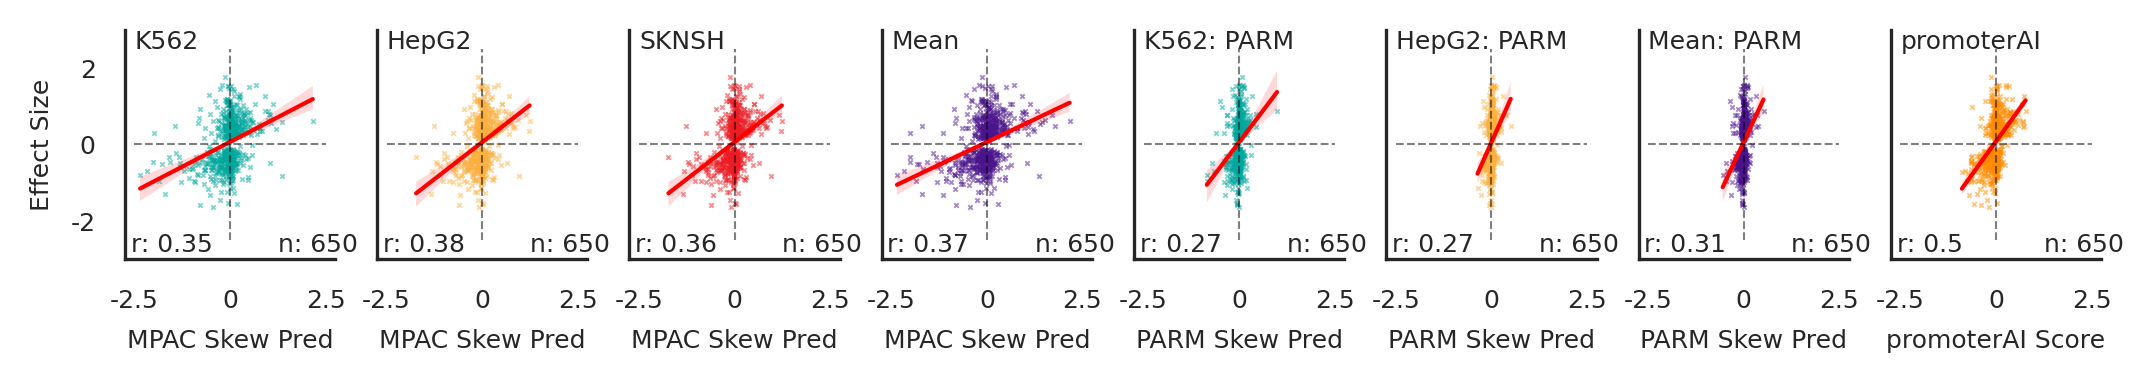

In [33]:
# plot all tissue variants
f = plt.figure(figsize=(8.5,2),dpi=300)
gs = f.add_gridspec(1,8)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# k562 #
with sns.axes_style('white'):
    ax_01 = f.add_subplot(gs[0,0])
    ax_01.set_aspect('equal')
    sns.regplot(data=highPIP_all_tissue_preds, x='k562_skew_pred', y='slope',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=0.1,
                color='#00A79D',
                alpha=0.5))
    ax_01.set_ylabel('Effect Size', fontsize = 6)
    ax_01.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_01.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    ax_01.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['k562_skew_pred'], 
                                            y=highPIP_all_tissue_preds['slope'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('K562', xy=(-2.5, 2.5), fontsize = 6)
# hepg2 #
with sns.axes_style('white'):
    ax_02 = f.add_subplot(gs[0,1], sharey=ax_01)
    ax_02.set_aspect('equal')
    sns.regplot(data=highPIP_all_tissue_preds, x='hepg2_skew_pred', y='slope',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=0.1,
                color='#FBB040',
                alpha=0.5))
    ax_02.set_ylabel('')
    ax_02.tick_params(labelleft=False)
    ax_02.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_02.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['hepg2_skew_pred'], 
                                            y=highPIP_all_tissue_preds['slope'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('HepG2', xy=(-2.5, 2.5), fontsize = 6)
# sknsh #
with sns.axes_style('white'):
    ax_03 = f.add_subplot(gs[0,2], sharey=ax_01)
    ax_03.set_aspect('equal')
    sns.regplot(data=highPIP_all_tissue_preds, x='hepg2_skew_pred', y='slope',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=0.1,
                color='#ED1C24',
                alpha=0.5))
    ax_03.set_ylabel('')
    ax_03.tick_params(labelleft=False)
    ax_03.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_03.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['sknsh_skew_pred'], 
                                            y=highPIP_all_tissue_preds['slope'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('SKNSH', xy=(-2.5, 2.5), fontsize = 6)
# mean
with sns.axes_style('white'):
    ax_04 = f.add_subplot(gs[0,3], sharey=ax_01)
    ax_04.set_aspect('equal')
    sns.regplot(data=highPIP_all_tissue_preds, x='mpac_max_skew', y='slope',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=0.1,
                color='#4A148C',
                alpha=0.5))
    ax_04.set_ylabel('')
    ax_04.tick_params(labelleft=False)
    ax_04.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_04.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['mpac_mean_skew'], 
                                            y=highPIP_all_tissue_preds['slope'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('Mean', xy=(-2.5, 2.5), fontsize = 6)
# k562 parm #
with sns.axes_style('white'):
    ax_05 = f.add_subplot(gs[0,4], sharey=ax_01)
    ax_05.set_aspect('equal')
    sns.regplot(data=highPIP_all_tissue_preds, x='parm_k562_pred', y='slope',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=0.1,
                color='#00A79D',
                alpha=0.5))
    ax_05.set_ylabel('')
    ax_05.tick_params(labelleft=False)
    ax_05.set_xlabel('PARM Skew Pred', fontsize = 6)
    ax_05.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    ax_05.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['parm_k562_pred'], 
                                            y=highPIP_all_tissue_preds['slope'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('K562: PARM', xy=(-2.5, 2.5), fontsize = 6)
# hepg2 parm #
with sns.axes_style('white'):
    ax_06 = f.add_subplot(gs[0,5], sharey=ax_01)
    ax_06.set_aspect('equal')
    sns.regplot(data=highPIP_all_tissue_preds, x='parm_hepg2_pred', y='slope',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=0.1,
                color='#FBB040',
                alpha=0.5))
    ax_06.set_ylabel('')
    ax_06.tick_params(labelleft=False)
    ax_06.set_xlabel('PARM Skew Pred', fontsize = 6)
    ax_06.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    ax_06.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['parm_hepg2_pred'], 
                                            y=highPIP_all_tissue_preds['slope'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('HepG2: PARM', xy=(-2.5, 2.5), fontsize = 6)
# mean parm #
with sns.axes_style('white'):
    ax_07 = f.add_subplot(gs[0,6], sharey=ax_01)
    ax_07.set_aspect('equal')
    sns.regplot(data=highPIP_all_tissue_preds, x='parm_mean_skew', y='slope',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=0.1,
                color='#4A148C',
                alpha=0.5))
    ax_07.set_ylabel('')
    ax_07.tick_params(labelleft=False)
    ax_07.set_xlabel('PARM Skew Pred', fontsize = 6)
    ax_07.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    ax_07.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['parm_mean_skew'], 
                                            y=highPIP_all_tissue_preds['slope'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('Mean: PARM', xy=(-2.5, 2.5), fontsize = 6)
# promoterAI #
with sns.axes_style('white'):
    ax_08 = f.add_subplot(gs[0,7], sharey=ax_01)
    ax_08.set_aspect('equal')
    sns.regplot(data=highPIP_all_tissue_preds, x='promoterAI_score', y='slope',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=0.1,
                color='darkorange',
                alpha=0.5))
    ax_08.set_ylabel('')
    ax_08.tick_params(labelleft=False)
    ax_08.set_xlabel('promoterAI Score', fontsize = 6)
    ax_08.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    ax_08.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.xlim((-2.75, 2.75))
    plt.ylim((-3, 3))
    plt.hlines(y=0, xmin=-2.5, xmax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.vlines(x=0, ymin=-2.5, ymax=2.5, linestyles='dashed', linewidth=.5, color='k', alpha=0.5)
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['promoterAI_score'], 
                                            y=highPIP_all_tissue_preds['slope'])[0], 2)}', xy=(-2.6, -2.8), fontsize = 6)
    plt.annotate('promoterAI', xy=(-2.5, 2.5), fontsize = 6)
sns.despine()

In [16]:
highPIP_posphylo = highPIP_all_tissue_preds[highPIP_all_tissue_preds['phyloP_470'] >= 0]

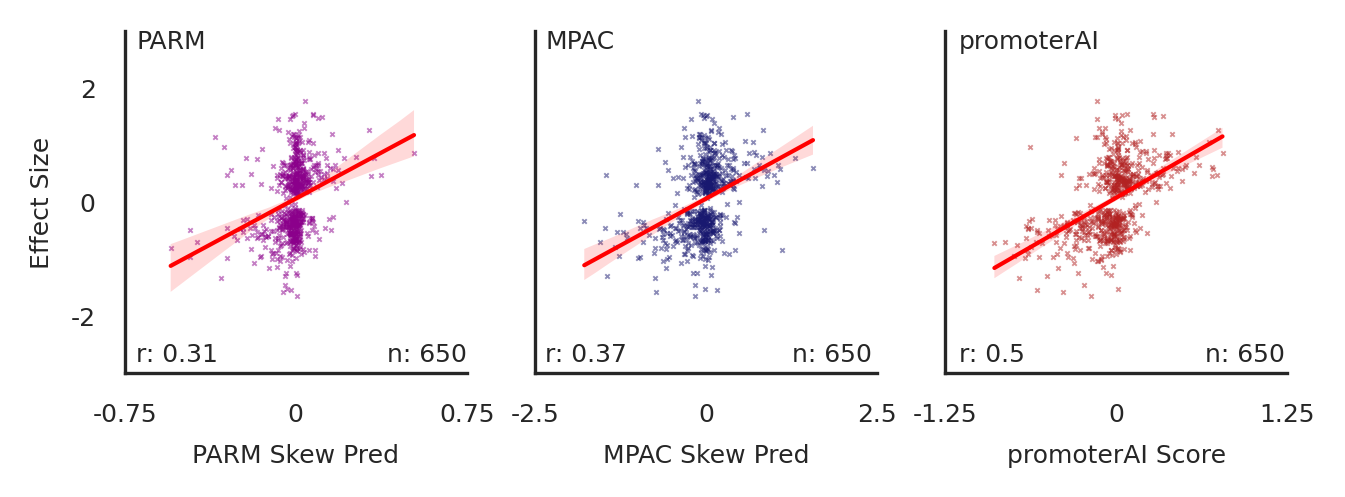

In [44]:
# plot all tissue variants
f = plt.figure(figsize=(5,2),dpi=300)
gs = f.add_gridspec(1,3)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# PARM  Mean #
with sns.axes_style('white'):
    ax_01 = f.add_subplot(gs[0,0])
    ax_01.set_box_aspect(1)
    sns.regplot(data=highPIP_all_tissue_preds, x='parm_mean_skew', y='slope',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=0.1,
                color='darkmagenta',
                alpha=0.5))
    ax_01.set_ylabel('Effect Size', fontsize = 6)
    ax_01.set_xlabel('PARM Skew Pred', fontsize = 6)
    ax_01.set_xticks([-0.75, 0, 0.75], [-0.75, 0, 0.75], fontsize = 6)
    ax_01.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.ylim((-3, 3))
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(0.4, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['parm_mean_skew'], 
                                            y=highPIP_all_tissue_preds['slope'])[0], 2)}', xy=(-0.7, -2.8), fontsize = 6)
    plt.annotate('PARM', xy=(-.7, 2.7), fontsize = 6)
# MPAC  Mean #
with sns.axes_style('white'):
    ax_02 = f.add_subplot(gs[0,1], sharey=ax_01)
    ax_02.set_box_aspect(1)
    sns.regplot(data=highPIP_all_tissue_preds, x='mpac_mean_skew', y='slope',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=0.1,
                color='midnightblue',
                alpha=0.5))
    ax_02.tick_params(labelleft=False)
    ax_02.set_ylabel('Effect Size', fontsize = 6)
    ax_02.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_02.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    ax_02.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    ax_02.set_ylabel('')
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['mpac_mean_skew'], 
                                            y=highPIP_all_tissue_preds['slope'])[0], 2)}', xy=(-2.35, -2.8), fontsize = 6)
    plt.annotate('MPAC', xy=(-2.35, 2.7), fontsize = 6)
# MPAC  Mean #
with sns.axes_style('white'):
    ax_03 = f.add_subplot(gs[0,2], sharey=ax_01)
    ax_03.set_box_aspect(1)
    sns.regplot(data=highPIP_all_tissue_preds, x='promoterAI_score', y='slope',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=0.1,
                color='firebrick',
                alpha=0.5))
    ax_03.tick_params(labelleft=False)
    ax_03.set_ylabel('Effect Size', fontsize = 6)
    ax_03.set_xlabel('promoterAI Score', fontsize = 6)
    ax_03.set_xticks([-1.25, 0, 1.25], [-1.25, 0, 1.25], fontsize = 6)
    ax_03.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    ax_03.set_ylabel('')
    plt.annotate(f'n: {len(highPIP_all_tissue_preds)}', xy=(0.65, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_all_tissue_preds['promoterAI_score'], 
                                            y=highPIP_all_tissue_preds['slope'])[0], 2)}', xy=(-1.15, -2.8), fontsize = 6)
    plt.annotate('promoterAI', xy=(-1.15, 2.7), fontsize = 6)
sns.despine()
plt.savefig('../plots/eQTL_effect_size_comparison_gtex_v10.pdf')

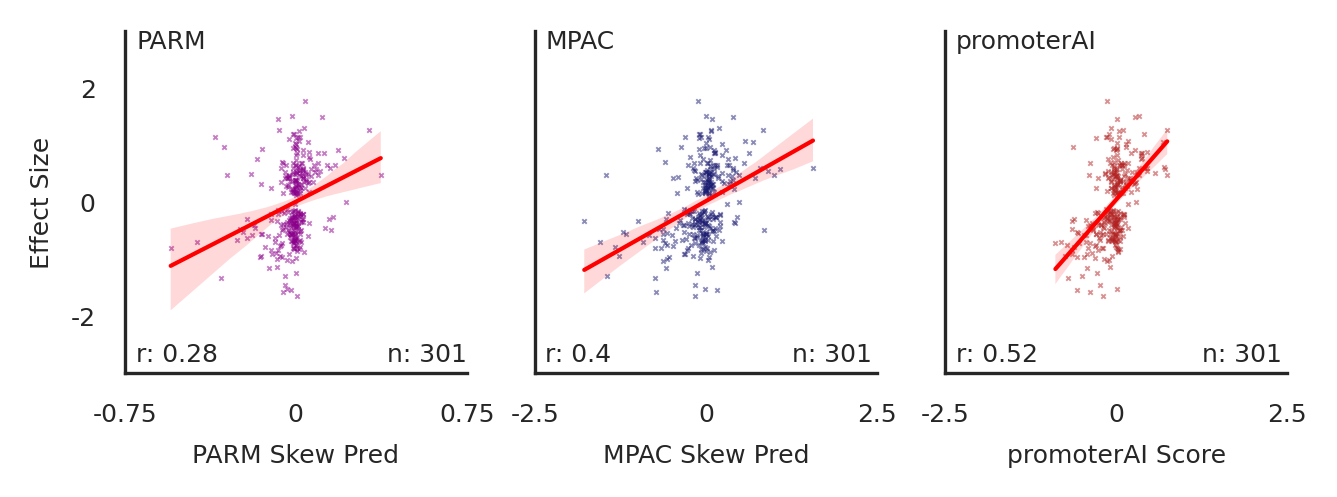

In [18]:
# plot all tissue variants
f = plt.figure(figsize=(5,2),dpi=300)
gs = f.add_gridspec(1,3)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# PARM  Mean #
with sns.axes_style('white'):
    ax_01 = f.add_subplot(gs[0,0])
    ax_01.set_box_aspect(1)
    sns.regplot(data=highPIP_posphylo, x='parm_mean_skew', y='slope',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=0.1,
                color='darkmagenta',
                alpha=0.5))
    ax_01.set_ylabel('Effect Size', fontsize = 6)
    ax_01.set_xlabel('PARM Skew Pred', fontsize = 6)
    ax_01.set_xticks([-0.75, 0, 0.75], [-0.75, 0, 0.75], fontsize = 6)
    ax_01.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    plt.ylim((-3, 3))
    plt.annotate(f'n: {len(highPIP_posphylo)}', xy=(0.4, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_posphylo['parm_mean_skew'], 
                                            y=highPIP_posphylo['slope'])[0], 2)}', xy=(-0.7, -2.8), fontsize = 6)
    plt.annotate('PARM', xy=(-.7, 2.7), fontsize = 6)
# MPAC  Mean #
with sns.axes_style('white'):
    ax_02 = f.add_subplot(gs[0,1], sharey=ax_01)
    ax_02.set_box_aspect(1)
    sns.regplot(data=highPIP_posphylo, x='mpac_mean_skew', y='slope',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=0.1,
                color='midnightblue',
                alpha=0.5))
    ax_02.tick_params(labelleft=False)
    ax_02.set_ylabel('Effect Size', fontsize = 6)
    ax_02.set_xlabel('MPAC Skew Pred', fontsize = 6)
    ax_02.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    ax_02.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    ax_02.set_ylabel('')
    plt.annotate(f'n: {len(highPIP_posphylo)}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_posphylo['mpac_mean_skew'], 
                                            y=highPIP_posphylo['slope'])[0], 2)}', xy=(-2.35, -2.8), fontsize = 6)
    plt.annotate('MPAC', xy=(-2.35, 2.7), fontsize = 6)
# MPAC  Mean #
with sns.axes_style('white'):
    ax_03 = f.add_subplot(gs[0,2], sharey=ax_01)
    ax_03.set_box_aspect(1)
    sns.regplot(data=highPIP_posphylo, x='promoterAI_score', y='slope',
        ci=99, marker="x", color=".3", line_kws=dict(color="r", linewidth=1),
        scatter_kws=dict(s=0.1,
                color='firebrick',
                alpha=0.5))
    ax_03.tick_params(labelleft=False)
    ax_03.set_ylabel('Effect Size', fontsize = 6)
    ax_03.set_xlabel('promoterAI Score', fontsize = 6)
    ax_03.set_xticks([-2.5, 0, 2.5], [-2.5, 0, 2.5], fontsize = 6)
    ax_03.set_yticks([-2,0,2], [-2,0,2], fontsize = 6)
    ax_03.set_ylabel('')
    plt.annotate(f'n: {len(highPIP_posphylo)}', xy=(1.25, -2.8), fontsize = 6)
    plt.annotate(f'r: {round(stats.pearsonr(x=highPIP_posphylo['promoterAI_score'], 
                                            y=highPIP_posphylo['slope'])[0], 2)}', xy=(-2.35, -2.8), fontsize = 6)
    plt.annotate('promoterAI', xy=(-2.35, 2.7), fontsize = 6)
sns.despine()
#plt.savefig('../plots/eQTL_effect_size_comparison_gtex_v10.pdf')

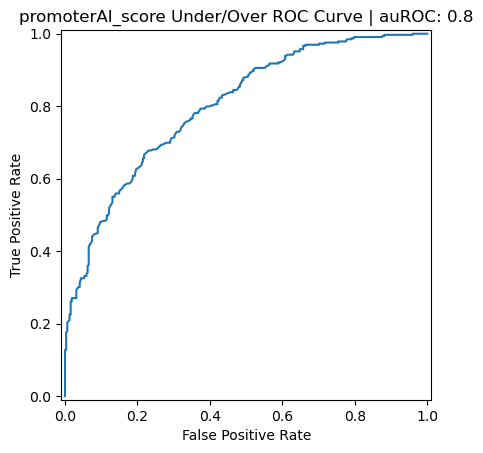

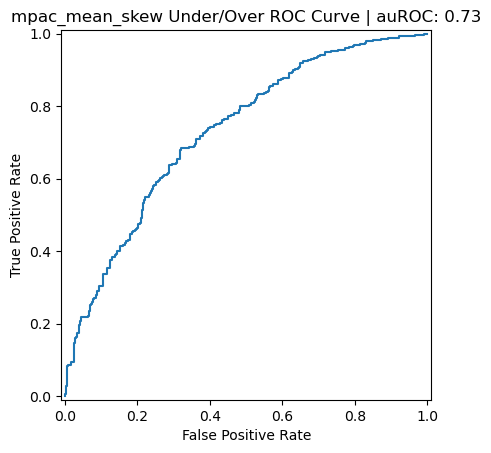

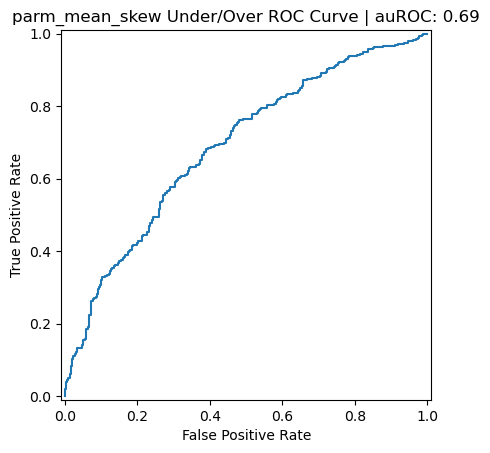

In [46]:
# calculate the auroc for each method
# label each variant as over/under
highPIP_all_tissue_preds.loc[:, 'over_under'] = ['over' if i >= 0 else 'under' for i in highPIP_all_tissue_preds['slope']]
# define a list of columns to iterate through for generating auROCs #
pred_cols = ['promoterAI_score',
             'mpac_mean_skew',
             'parm_mean_skew']
# add binarized column for calculating ROC
highPIP_all_tissue_preds.loc[:,'auroc_tf'] = [0 if i == 'under' else 1 for i in highPIP_all_tissue_preds['over_under']]
# iterate through prediction columns and calculate auROC for each prediction #
# make an empty list for storing prediction type #
u_o_col_name = []
# make an empty list for storing auROC score #
u_o_auroc = []
# make an empty list for storing task #
u_o_task = []
# make an empty dictionary for storing auroc curve results #
u_o_dict = {}
for pred in pred_cols:
    # update col name list #
    u_o_col_name.append(pred)
    # generate auROC curve #
    fpr, tpr, thresh = metrics.roc_curve(highPIP_all_tissue_preds['auroc_tf'],
                                         highPIP_all_tissue_preds[pred])
    # generate auROC score #
    auroc_score = metrics.roc_auc_score(highPIP_all_tissue_preds['auroc_tf'],
                                         highPIP_all_tissue_preds[pred])
    # display roc curve #
    RocCurveDisplay(fpr=fpr,
                    tpr=tpr).plot()
    plt.title(f'{pred} Under/Over ROC Curve | auROC: {round(auroc_score, 2)}')
    # update auroc score list #
    u_o_auroc.append(auroc_score)
    # add auROC results to dict #
    u_o_dict.update({pred : (fpr, tpr, thresh, auroc_score)})
    # add task annotation to list #
    u_o_task.append('Under/Over')
#%%
# make a dataframe for plotting summary #
u_o_auroc_df = pd.DataFrame({'Task' : u_o_task,
                             'auROC' : u_o_auroc,
                             'Prediction' : u_o_col_name})